# Titanic Survival: Exploratory Data Analysis
**Dataset:** `Titanic-Dataset.csv` (891 passengers, 12 columns)

**Goal:** understand which passenger characteristics (sex, class, age, family size, fare, port of
embarkation) were related to survival, and prepare a clean dataset that is ready for a classifier.

| Column | Meaning |
|---|---|
| Survived | 0 = No, 1 = Yes (target) |
| Pclass | Ticket class (1 = 1st, 2 = 2nd, 3 = 3rd) |
| SibSp / Parch | # siblings/spouses, # parents/children aboard |
| Fare | Ticket price |
| Embarked | Port: C = Cherbourg, Q = Queenstown, S = Southampton |

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid')

## 1. Load & inspect

In [2]:
df = pd.read_csv('datasets/Titanic-Dataset.csv')
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [3]:
print(df.shape)
df.info()

(891, 12)
<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 118.9 KB


In [4]:
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


## 2. Missing values

In [5]:
missing = df.isnull().sum()
pct = (missing / len(df) * 100).round(2)
pd.DataFrame({'missing': missing, '%': pct}).query('missing > 0')

,missing,%
Age,177,19.87
Cabin,687,77.10
Embarked,2,0.22


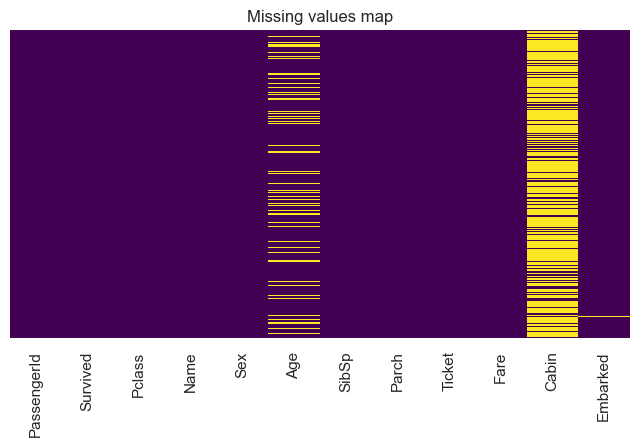

In [6]:
plt.figure(figsize=(8, 4))
sns.heatmap(df.isnull(), cbar=False, yticklabels=False, cmap='viridis')
plt.title('Missing values map')
plt.show()

## 3. Data cleaning
- **Age** (~20% missing): fill with the median age of each *title* (Mr, Mrs, Miss, Master), which is more accurate than one global median.
- **Embarked** (2 missing): fill with the mode.
- **Cabin** (~77% missing): too sparse to impute, so keep only a `HasCabin` flag.

In [7]:
data = df.copy()
data['Title'] = data['Name'].str.extract(r',\s*([^\.]+)\.')
data['Title'] = data['Title'].replace({'Mlle': 'Miss', 'Ms': 'Miss', 'Mme': 'Mrs'})
rare = data['Title'].value_counts()[lambda s: s < 10].index
data['Title'] = data['Title'].replace(rare, 'Rare')
data['Title'].value_counts()

Title
Mr        517
Miss      185
Mrs       126
Master     40
Rare       23
Name: count, dtype: int64

In [8]:
data['Age'] = data['Age'].fillna(data.groupby('Title')['Age'].transform('median'))
data['Embarked'] = data['Embarked'].fillna(data['Embarked'].mode()[0])
data['HasCabin'] = data['Cabin'].notnull().astype(int)
data = data.drop(columns=['Cabin'])
data.isnull().sum().sum()

np.int64(0)

## 4. Feature engineering

In [9]:
data['FamilySize'] = data['SibSp'] + data['Parch'] + 1
data['IsAlone'] = (data['FamilySize'] == 1).astype(int)
data['AgeGroup'] = pd.cut(data['Age'], bins=[0, 12, 18, 35, 60, 80],
                          labels=['Child', 'Teen', 'Young Adult', 'Adult', 'Senior'])
data['FareBand'] = pd.qcut(data['Fare'], 4, labels=['Low', 'Mid', 'High', 'Very High'])
data[['Name', 'Title', 'Age', 'AgeGroup', 'FamilySize', 'IsAlone', 'FareBand']].head()

,Name,Title,Age,AgeGroup,FamilySize,IsAlone,FareBand
0,"Braund, Mr. Owen Harris",Mr,22.0,Young Adult,2,0,Low
1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",Mrs,38.0,Adult,2,0,Very High
2,"Heikkinen, Miss. Laina",Miss,26.0,Young Adult,1,1,Mid
3,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",Mrs,35.0,Young Adult,2,0,Very High
4,"Allen, Mr. William Henry",Mr,35.0,Young Adult,1,1,Mid


## 5. Univariate analysis

Overall survival rate: 38.38 %


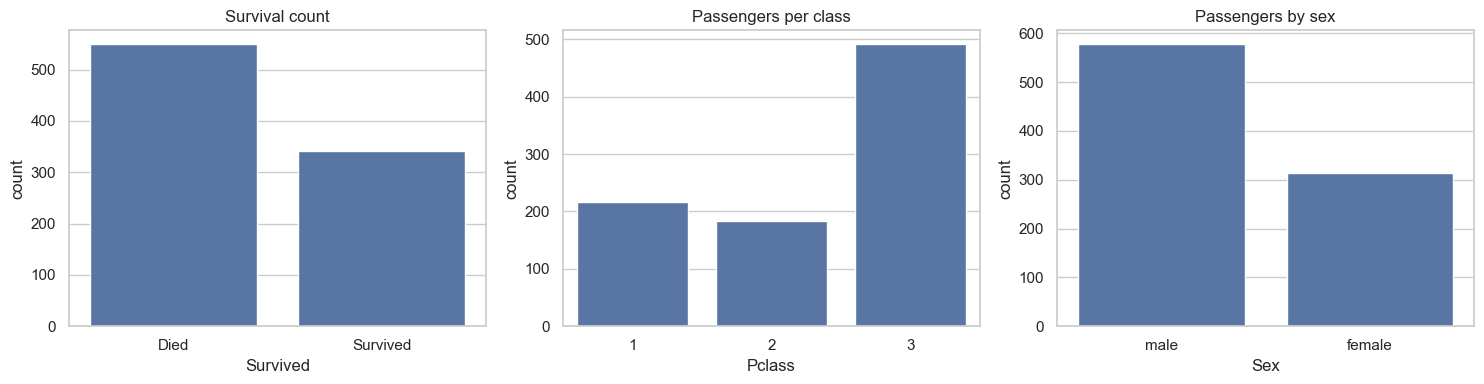

In [10]:
print('Overall survival rate:', round(data['Survived'].mean() * 100, 2), '%')
fig, ax = plt.subplots(1, 3, figsize=(15, 4))
sns.countplot(x='Survived', data=data, ax=ax[0]); ax[0].set_xticks([0, 1], ['Died', 'Survived']); ax[0].set_title('Survival count')
sns.countplot(x='Pclass', data=data, ax=ax[1]); ax[1].set_title('Passengers per class')
sns.countplot(x='Sex', data=data, ax=ax[2]); ax[2].set_title('Passengers by sex')
plt.tight_layout(); plt.show()

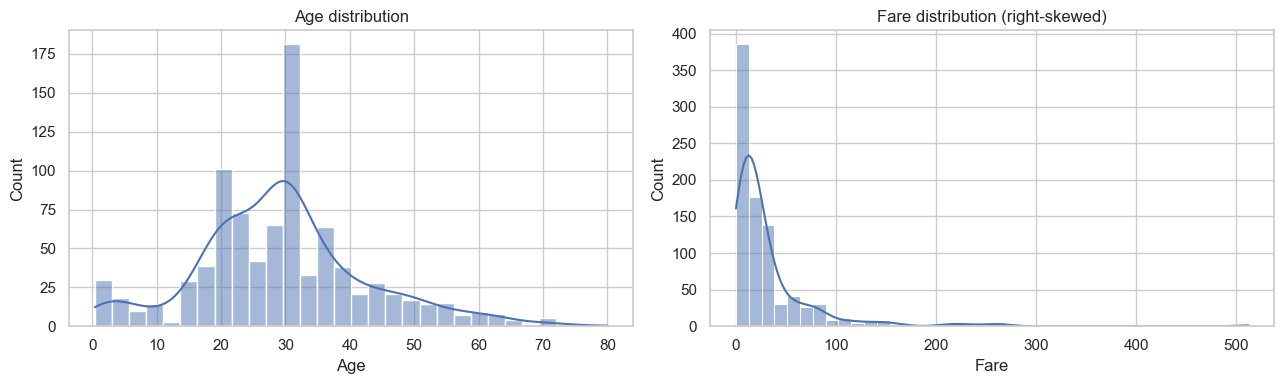

Fare skewness: 4.79


In [11]:
fig, ax = plt.subplots(1, 2, figsize=(13, 4))
sns.histplot(data['Age'], bins=30, kde=True, ax=ax[0]); ax[0].set_title('Age distribution')
sns.histplot(data['Fare'], bins=40, kde=True, ax=ax[1]); ax[1].set_title('Fare distribution (right-skewed)')
plt.tight_layout(); plt.show()
print('Fare skewness:', round(data['Fare'].skew(), 2))

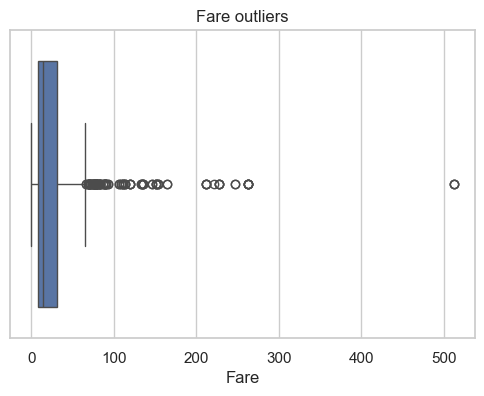

Outliers by IQR rule: 116


In [12]:
plt.figure(figsize=(6, 4))
sns.boxplot(x=data['Fare'])
plt.title('Fare outliers')
plt.show()
q1, q3 = data['Fare'].quantile([0.25, 0.75])
iqr = q3 - q1
print('Outliers by IQR rule:', (data['Fare'] > q3 + 1.5 * iqr).sum())

## 6. Bivariate analysis: survival vs features

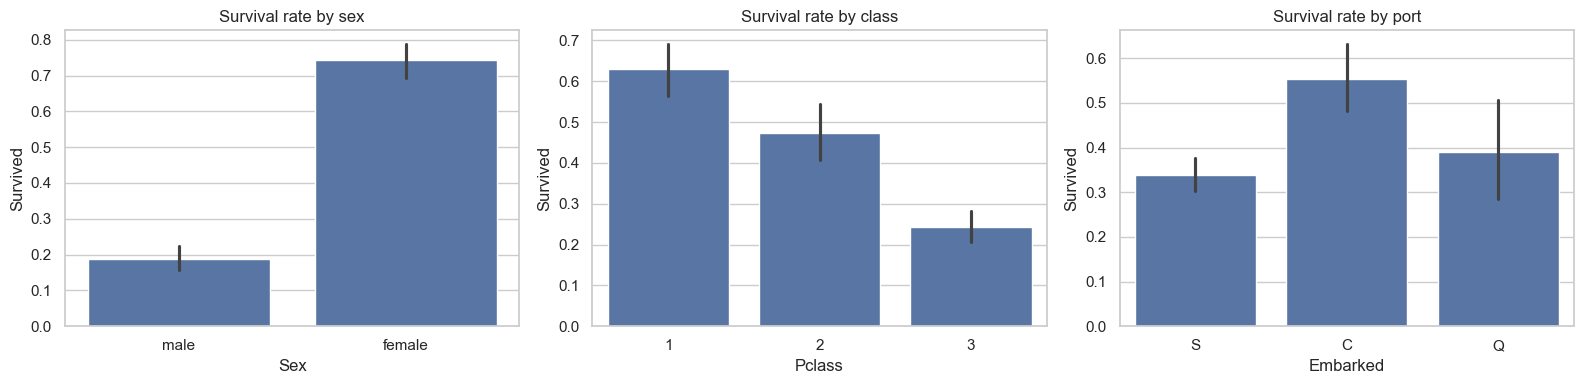

In [13]:
fig, ax = plt.subplots(1, 3, figsize=(16, 4))
sns.barplot(x='Sex', y='Survived', data=data, ax=ax[0]); ax[0].set_title('Survival rate by sex')
sns.barplot(x='Pclass', y='Survived', data=data, ax=ax[1]); ax[1].set_title('Survival rate by class')
sns.barplot(x='Embarked', y='Survived', data=data, ax=ax[2]); ax[2].set_title('Survival rate by port')
plt.tight_layout(); plt.show()

In [14]:
data.groupby(['Pclass', 'Sex'])['Survived'].mean().unstack().round(3)

Sex,female,male
Pclass,,
1,0.968,0.369
2,0.921,0.157
3,0.500,0.135


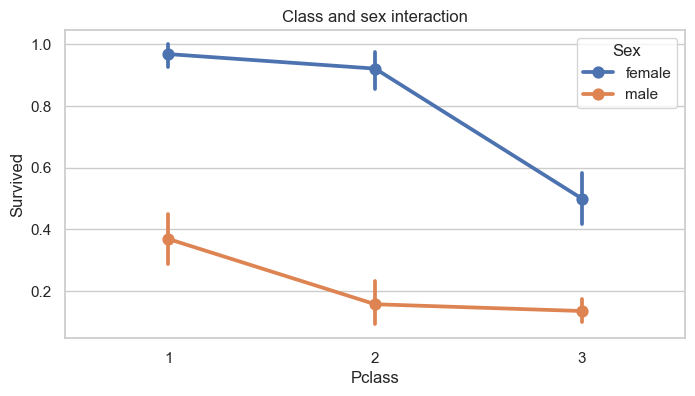

In [15]:
plt.figure(figsize=(8, 4))
sns.pointplot(x='Pclass', y='Survived', hue='Sex', data=data)
plt.title('Class and sex interaction')
plt.show()

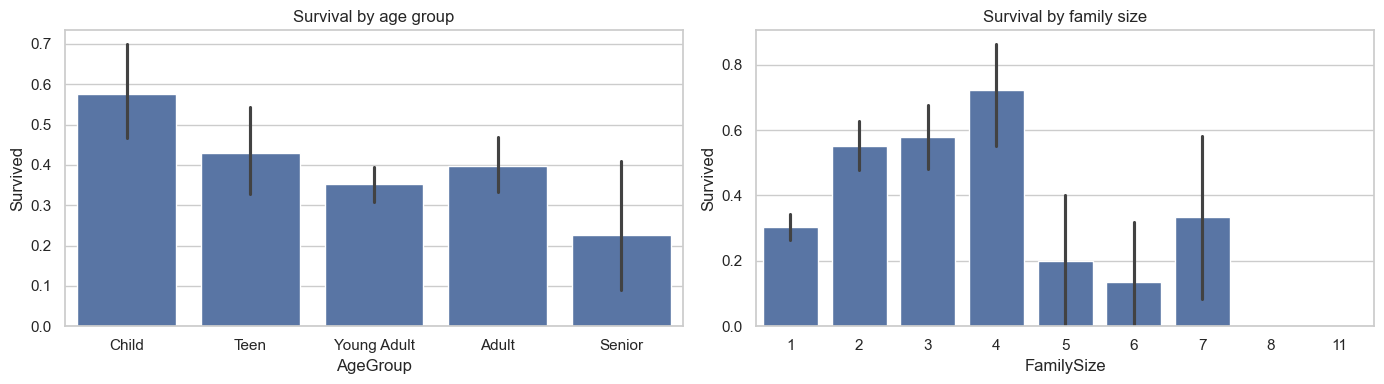

In [16]:
fig, ax = plt.subplots(1, 2, figsize=(14, 4))
sns.barplot(x='AgeGroup', y='Survived', data=data, ax=ax[0]); ax[0].set_title('Survival by age group')
sns.barplot(x='FamilySize', y='Survived', data=data, ax=ax[1]); ax[1].set_title('Survival by family size')
plt.tight_layout(); plt.show()

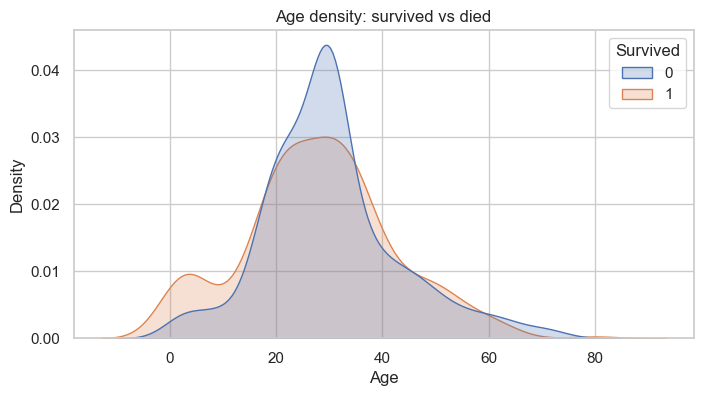

In [17]:
plt.figure(figsize=(8, 4))
sns.kdeplot(data=data, x='Age', hue='Survived', fill=True, common_norm=False)
plt.title('Age density: survived vs died')
plt.show()

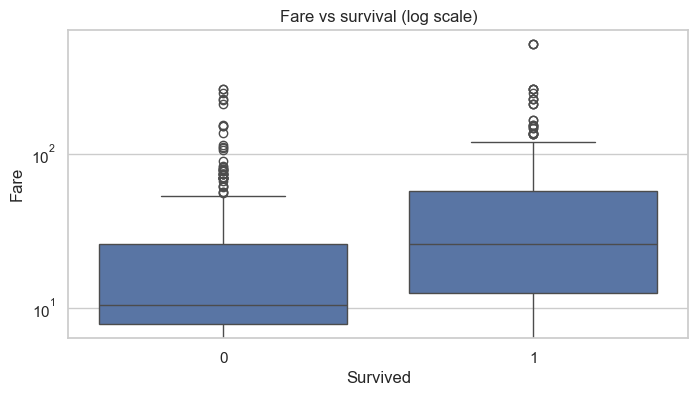

In [18]:
plt.figure(figsize=(8, 4))
sns.boxplot(x='Survived', y='Fare', data=data)
plt.yscale('log')
plt.title('Fare vs survival (log scale)')
plt.show()

In [19]:
data.groupby('Title')['Survived'].agg(['mean', 'count']).round(3).sort_values('mean', ascending=False)

,mean,count
Title,,
Mrs,0.794,126
Miss,0.703,185
Master,0.575,40
Rare,0.348,23
Mr,0.157,517


## 7. Correlation

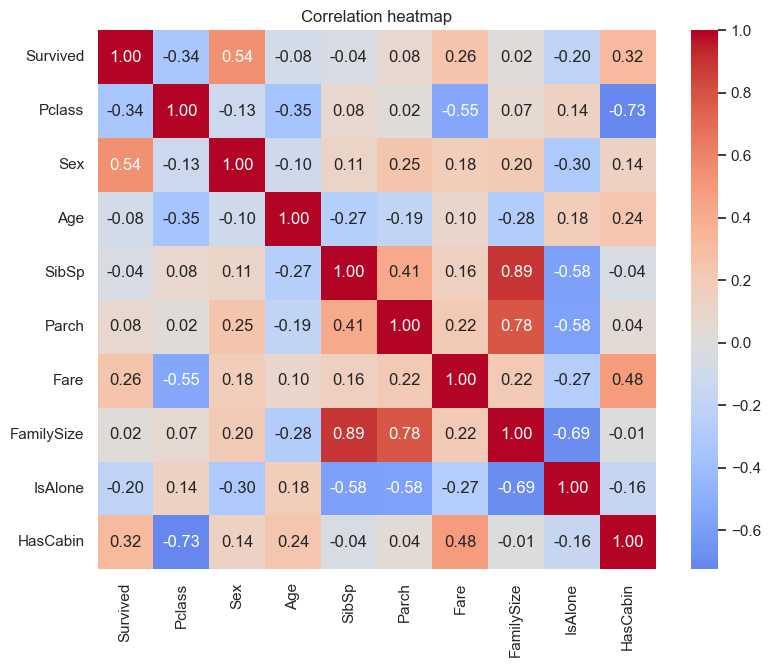

In [20]:
corr_df = data.assign(Sex=data['Sex'].map({'male': 0, 'female': 1}))
cols = ['Survived', 'Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'FamilySize', 'IsAlone', 'HasCabin']
plt.figure(figsize=(9, 7))
sns.heatmap(corr_df[cols].corr(), annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Correlation heatmap')
plt.show()

In [21]:
corr_df[cols].corr()['Survived'].drop('Survived').sort_values(key=abs, ascending=False).round(3)

Sex           0.543
Pclass       -0.338
HasCabin      0.317
Fare          0.257
IsAlone      -0.203
Parch         0.082
Age          -0.079
SibSp        -0.035
FamilySize    0.017
Name: Survived, dtype: float64

## 8. Model-ready dataset
The categorical columns are encoded and the ID/text columns dropped, so the data can go straight into `LogisticRegression`.

In [22]:
model_df = data.drop(columns=['PassengerId', 'Name', 'Ticket', 'AgeGroup', 'FareBand'])
model_df['Sex'] = model_df['Sex'].map({'male': 0, 'female': 1})
model_df = pd.get_dummies(model_df, columns=['Embarked', 'Title'], drop_first=True, dtype=int)
model_df.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,HasCabin,FamilySize,IsAlone,Embarked_Q,Embarked_S,Title_Miss,Title_Mr,Title_Mrs,Title_Rare
0,0,3,0,22.0,1,0,7.2500,0,2,0,0,1,0,1,0,0
1,1,1,1,38.0,1,0,71.2833,1,2,0,0,0,0,0,1,0
2,1,3,1,26.0,0,0,7.9250,0,1,1,0,1,1,0,0,0
3,1,1,1,35.0,1,0,53.1000,1,2,0,0,1,0,0,1,0
4,0,3,0,35.0,0,0,8.0500,0,1,1,0,1,0,1,0,0


Baseline accuracy (always predict "died"): 0.615
Logistic Regression accuracy            : 0.827


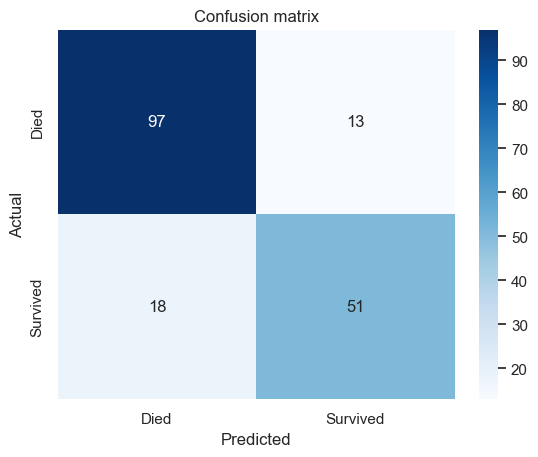

In [23]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix

X = model_df.drop(columns='Survived')
y = model_df['Survived']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
clf = LogisticRegression(max_iter=1000).fit(X_train, y_train)
y_pred = clf.predict(X_test)
print('Baseline accuracy (always predict "died"):', round(1 - y_test.mean(), 3))
print('Logistic Regression accuracy            :', round(accuracy_score(y_test, y_pred), 3))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues',
            xticklabels=['Died', 'Survived'], yticklabels=['Died', 'Survived'])
plt.xlabel('Predicted'); plt.ylabel('Actual'); plt.title('Confusion matrix')
plt.show()

## 9. Conclusions
1. **Only ~38% of passengers survived.** The classes are imbalanced, so accuracy must be compared to a ~62% baseline.
2. **Sex was the strongest factor:** ~74% of women survived versus ~19% of men ("women and children first").
3. **Class mattered:** 1st class survived at ~63%, 3rd class at ~24%. Almost all 1st/2nd-class women survived.
4. **Children (and the `Master` title) had higher survival** than adult men.
5. **Small families (2–4) did best.** Passengers travelling alone or in very large families had lower survival.
6. **Fare and having a cabin record were both positively related** to survival. They act as proxies for wealth and class.
7. Passengers from **Cherbourg (C)** survived more often, largely because more of them were in 1st class.
8. A simple logistic regression on the cleaned features reaches **82.7% accuracy** against a **61.5% baseline**, so the engineered features are useful.